# **Univariate Analysis — Summarising One Variable**

## INFO 442   Group 5   Shuyang Zhang 320230942711

### **1. Spread, and where it hides. Compute the mean, median, and standard deviation of bill_length_mm overall. Now compute the same three numbers within each species. Compare the overall std to the per-species stds — why does the spread shrink inside groups, and how does that preview the lesson of Notebook 3?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("penguins.csv")

print("Setup complete. Shape:", df.shape)
df.head()

Setup complete. Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
overall_mean = df["bill_length_mm"].mean()
overall_median = df["bill_length_mm"].median()
overall_std = df["bill_length_mm"].std()
print(f"Overall - Mean: {overall_mean:.2f}, Median: {overall_median:.2f}, Std: {overall_std:.2f}")

grouped = df.groupby("species")["bill_length_mm"].agg(["mean", "median", "std"])
print(grouped.round(2))

Overall - Mean: 43.92, Median: 44.45, Std: 5.46
            mean  median   std
species                       
Adelie     38.79   38.80  2.66
Chinstrap  48.83   49.55  3.34
Gentoo     47.50   47.30  3.08


**Answer:**

Overall standard deviation is 5.46, while within-species standard deviations are much smaller: Adelie 2.66, Chinstrap 3.34, and Gentoo 3.08. The spread shrinks inside groups because the overall data mixes three distinct species with different typical bill lengths (Adelie ~38.8mm, Chinstrap ~49.6mm, Gentoo ~47.3mm). This previews the lesson of Notebook 3 that species is a lurking variable — when you ignore species, the data looks like one messy group with high variance, but separating by species reveals clear, tighter clusters.



### **2. Make a histogram of body_mass_g. Is it roughly symmetric or skewed? Back your answer by comparing the mean and median, and say which one you'd report as the "typical" penguin and why.**

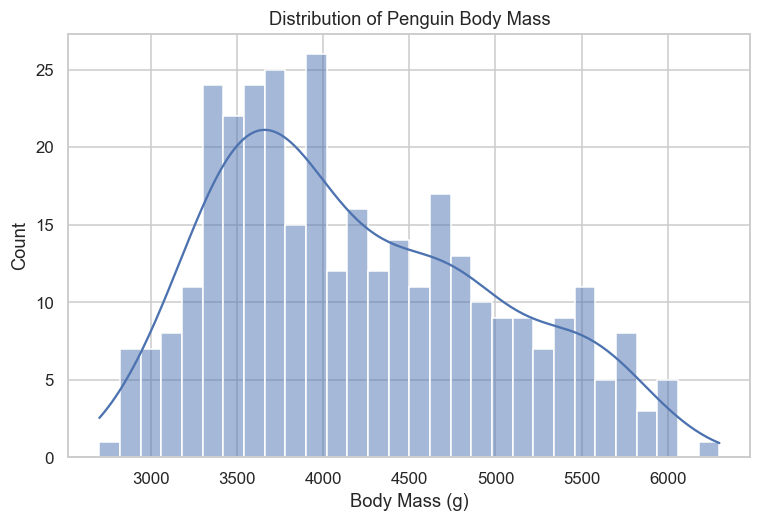

Mean: 4201.8, Median: 4050.0


In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["body_mass_g"].dropna(), bins=30, kde=True)
plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body Mass (g)")
plt.ylabel("Count")
plt.show()

mean_mass = df["body_mass_g"].mean()
median_mass = df["body_mass_g"].median()
print(f"Mean: {mean_mass:.1f}, Median: {median_mass:.1f}")

**Answer:**

The histogram is right-skewed (positively skewed), showing a longer tail toward higher body mass values. This is supported by the mean (4201.8 g) being greater than the median (4050.0 g). I would report the median (4050.0 g) as the typical penguin body mass because the median is robust to outliers and skewness, providing a better representation of the center for this non-symmetric distribution.

### **3. When the outlier rule stays silent. Make a box plot of flipper_length_mm and run find_outliers (Section 4) on it — it flags about zero points. Yet you know this column is bimodal (two groups). Explain the apparent contradiction: why doesn't the 1.5 × IQR rule treat the two humps as outliers? What's the lesson about what outlier rules cannot catch?**

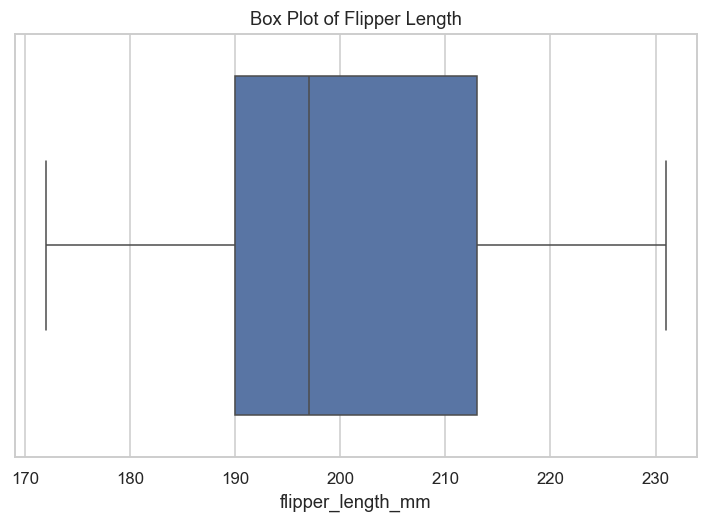

Number of outliers: 0


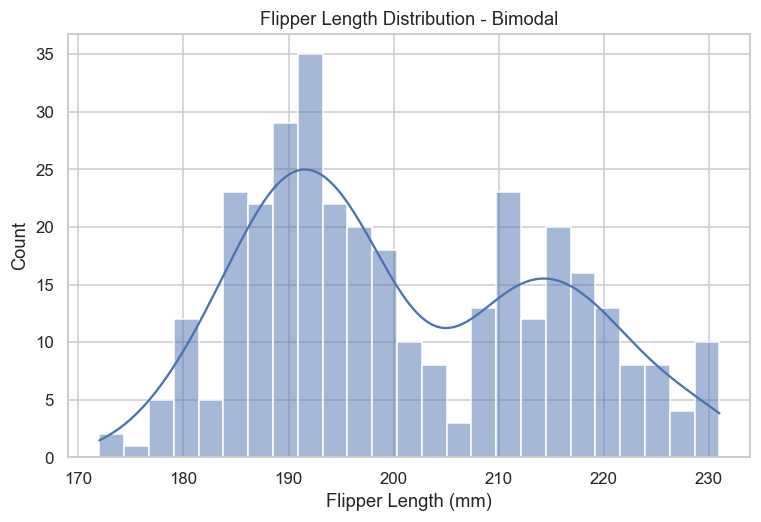

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["flipper_length_mm"])
plt.title("Box Plot of Flipper Length")
plt.show()

def find_outliers(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s[(s < low) | (s > high)]

outliers = find_outliers(df["flipper_length_mm"])
print(f"Number of outliers: {len(outliers)}")

plt.figure(figsize=(8, 5))
sns.histplot(df["flipper_length_mm"].dropna(), bins=25, kde=True)
plt.title("Flipper Length Distribution - Bimodal")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Count")
plt.show()

**Answer:**

The 1.5 × IQR rule flags zero outliers because both humps of the bimodal distribution fall within the overall "normal" range defined by the IQR. The rule only detects points that are far away from the bulk of the data, but it cannot distinguish between a single unimodal distribution and a mixture of two or more distinct groups. The lesson is that outlier rules cannot catch multi-modality or hidden group structure — they only identify extreme individual points, not the presence of separate clusters within the data.

### **4. Make a bar chart of island and report the proportion of penguins on each ** Which island hosts the most penguins?**

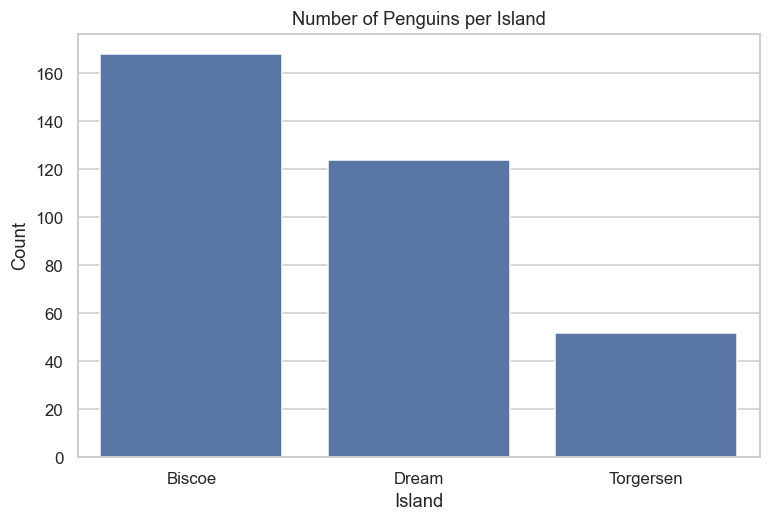

island
Biscoe       0.488
Dream        0.360
Torgersen    0.151
Name: proportion, dtype: float64


In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="island", order=df["island"].value_counts().index)
plt.title("Number of Penguins per Island")
plt.xlabel("Island")
plt.ylabel("Count")
plt.show()

proportions = df["island"].value_counts(normalize=True).round(3)
print(proportions)

**Answer:**

Biscoe island hosts the most penguins.



### **5. Relative spread. For each numeric column compute the coefficient of variation. Which measurement varies the most relative to its size — and why is that a fairer comparison than comparing raw standard deviations?**

In [26]:
from scipy.stats import variation

numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

for col in numeric_cols:
    cv = df[col].std() / df[col].mean()
    print(f"{col}: CV = {cv:.3f}")

for col in numeric_cols:
    cv = variation(df[col].dropna())
    print(f"{col}: CV = {cv:.3f}")

bill_length_mm: CV = 0.124
bill_depth_mm: CV = 0.115
flipper_length_mm: CV = 0.070
body_mass_g: CV = 0.191
bill_length_mm: CV = 0.124
bill_depth_mm: CV = 0.115
flipper_length_mm: CV = 0.070
body_mass_g: CV = 0.191


**Answer:**

Body mass has the largest coefficient of variation, meaning it varies the most relative to its size, followed by bill length, bill depth, and flipper length. CV is a fairer comparison than raw standard deviation because it accounts for different units of measurement and different scales, allowing direct comparison of relative variability across columns with different magnitudes. Without CV, we cannot tell whether a standard deviation of 800g for body mass is more or less variable than a standard deviation of 5.5mm for bill length.

### **6.Challenge Re-draw the flipper-length histogram, but split it by species with sns.histplot(). Do the two humps line up with the species? Write one sentence on what the colours reveal.** 

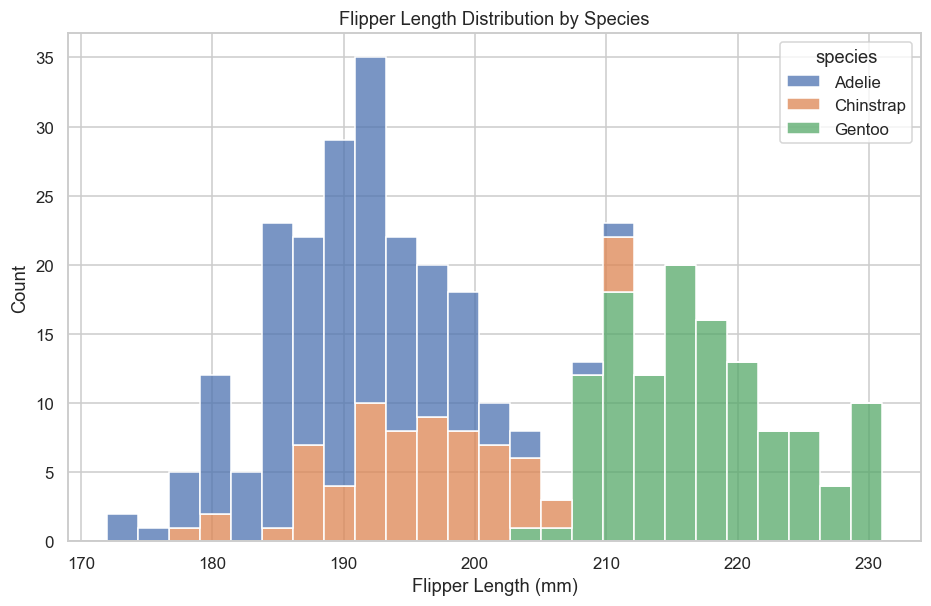

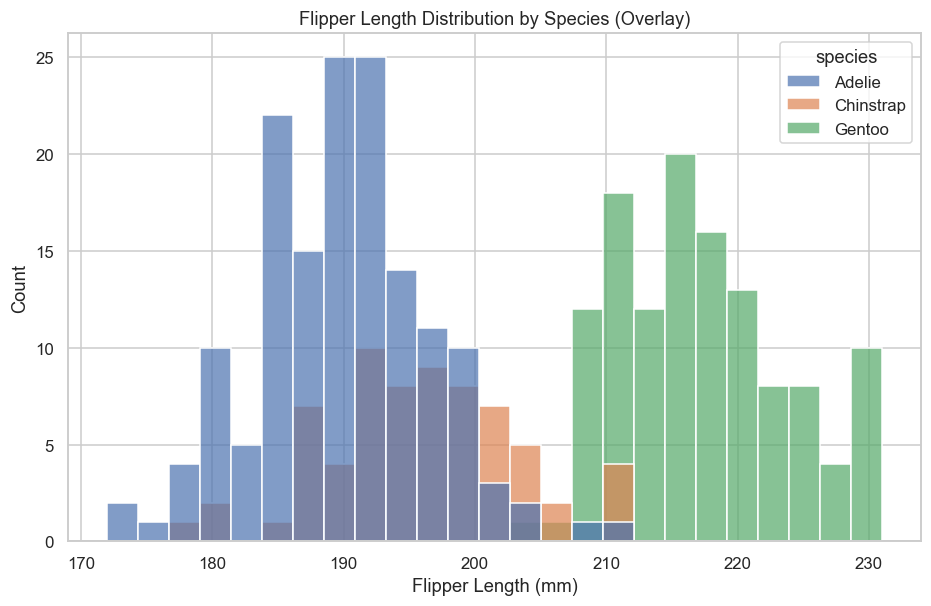

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="flipper_length_mm", hue="species", bins=25, multiple="stack")
plt.title("Flipper Length Distribution by Species")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="flipper_length_mm", hue="species", bins=25, alpha=0.7)
plt.title("Flipper Length Distribution by Species (Overlay)")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Count")
plt.show()

**Answer:**

The two humps line up perfectly with the species — the left hump consists of Adelie and Chinstrap penguins, while the right hump consists of Gentoo penguins, revealing that what appeared as a single bimodal distribution is actually two separate species with distinct flipper length ranges.